# TN2 — Tầm nhìn của DS-TCN 64 kênh

## Câu hỏi

Cấu hình nền có tầm nhìn **61 mẫu** trên cửa sổ vào **200 mẫu** — chỉ thấy 30
phần trăm cửa sổ, tức 1,2 giây ở 50 Hz, chưa tới một nhịp thở dài khoảng 4 giây.

Điểm hiện tại của nó: **0,760878 ± 0,003095 (3 seed)**.

**Mở rộng tầm nhìn tới quanh 200 mẫu có làm khá lên không?**

## Thang thí nghiệm

Giữ nguyên **4 khối**, chỉ đổi bề rộng kernel. Ở cùng số khối, kernel tăng làm
trọng số depthwise tăng, nhưng phần pointwise mới chiếm đa số — nên số tham số
thay đổi ít:

| kernel | tầm nhìn | phủ cửa sổ | tham số | so nền |
|---:|---:|---:|---:|---:|
| 3 | 61 | 30% | 37.081 | — *(đã chạy)* |
| **5** | 121 | 60% | **38.105** | +2,8% |
| **7** | 181 | 90% | **39.129** | +5,5% |
| **9** | 241 | 100% | **40.153** | +8,3% |
| **11** | 301 | 100% | **41.177** | +11,0% |
| **13** | 361 | 100% | **42.201** | +13,8% |

**Tầm nhìn gấp 5,9 lần mà tham số chỉ chênh 13,8 phần trăm.** Nếu điểm đổi
theo thang này thì gần như chắc do tầm nhìn, không do sức chứa.

Cách khác — tăng số khối — làm tham số nhảy tới 49 phần trăm, đổi hai biến cùng
lúc, không tách được.

Năm cấu hình bắc qua mốc 200: hai dưới (121, 181), một vừa đủ (241), hai thừa
(301, 361). Lên tới 241 rồi phẳng nghĩa là phủ hết cửa sổ là đủ; còn lên tiếp
nghĩa là tầm nhìn dài hơn cửa sổ vẫn có ích.

`k=3` không chạy lại vì đã có.

## Chạy vòng sàng lọc

Mỗi cấu hình **một fold `val_KL`** — train ABCDEF, chấm K và L, 218.088 cửa sổ.
Năm cấu hình mất khoảng **45 phút** thay vì gấp bốn.

**Hai điều bắt buộc nhớ**, đo trên tám cấu hình TN1 có đủ ba seed:

**1. Điểm một fold không so được với `cv_score` bốn fold.** `val_KL` là fold dễ
nhất; điểm trên nó cao hơn trung bình **+0,040**, mức chênh không đều, từ +0,020
tới +0,070 tuỳ cấu hình.

**2. Thứ hạng có thể đảo.** BiLSTM-41 đứng chót trên bốn fold nhưng hạng ba nếu
chỉ nhìn `val_KL`; DS-TCN-64 thì từ hạng sáu xuống chót.

Vòng này dùng để **loại**, không dùng để **chọn**. Chi tiết: `docs/SANG_LOC.md`.

`run_cv.py` **không ghi dòng `TONG`** khi thiếu fold, nên số sàng lọc không lọt
vào bảng `compare_cv`. Muốn xác nhận thì chạy lại **bỏ `--folds`** — fold đã
xong được bỏ qua, dòng `TONG` tự có.

## Mốc để đặt cạnh

So **một fold với một fold**. Điểm `val_KL` seed 0:

| | tham số | val_KL |
|---|---:|---:|
| LSTM-352 | 1.502.713 | 0,8257 |
| LSTM-67 | 56.908 | 0,8211 |
| DS-TCN-64 (TN1 gốc) | 56.281 | 0,7723 |

Nhóm kết quả `tn2_rf`, tách khỏi `tn2` của thí nghiệm RevIN.

## 1. Chuẩn bị Colab

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Tải mã nguồn. Cờ `--folds` và `--norm none` chỉ có ở bản mới.

In [2]:
!rm -rf /content/UWB_RADAR
!git clone -q https://github.com/quangminhho004-blip/UWB_RADAR.git /content/UWB_RADAR
%cd /content/UWB_RADAR
!python scripts/setup_colab.py

/content/UWB_RADAR

thư mục làm việc : /content/UWB_RADAR
commit đồ án     : 00f79dc
commit MobiVital : 4319731 (đã ghim)
GPU              : NVIDIA L4, 23034 MiB


Lấy `by_user/` và `windows/` từ Drive.

In [3]:
!python scripts/restore_processed_data_on_drive.py

by_user   : bung /content/drive/MyDrive/mobivital/by_user.tar ...
            12 tệp
windows   : bung /content/drive/MyDrive/mobivital/windows.tar.gz ...
            dev_cv 8 tệp, final_train có

2.5G	data/processed/by_user
503M	data/processed/windows


Khôi phục kết quả đã có từ Drive.

**Ô clone ở trên xoá `runs/`.** Không có bước này thì fold đã chạy bị train lại.
Chưa có kết quả cũ thì ô này không in gì.

In [ ]:
# Khôi phục kết quả đã chạy trước khi phiên bị ngắt.
#
# Mỗi tệp nén chứa một bản runs/<thực nghiệm>/summary.csv của riêng nó. Giải
# hết vào cùng một thư mục runs/ thì tệp giải sau ĐÈ summary.csv của tệp trước.
# Mà sorted() xếp "..._a0_corr0.9..." đứng SAU "..._a0.9_corr0.9...", vì trong
# bảng mã ký tự "_" lớn hơn "." — nên bản ít dòng nhất lại là bản đè cuối cùng.
# Sửa: mỗi tệp nén giải vào một thư mục tạm riêng, gộp mọi dòng lại rồi mới ghi
# runs/summary.csv một lần. Thứ tự giải nén không còn ảnh hưởng gì nữa.
import csv, glob, os, shutil, subprocess, tempfile

MAU_ZIP = "/content/drive/MyDrive/mobivital/tn2_rf_*c64*.zip"

rows, seen = [], set()

def collect(summary_path):
    for r in csv.DictReader(open(summary_path)):
        key = (r.get("experiment"), r.get("run_id"))
        if key not in seen:
            seen.add(key)
            rows.append(r)

for f in sorted(glob.glob(MAU_ZIP)):
    tmp = tempfile.mkdtemp()
    subprocess.run(["unzip", "-oq", f, "-d", tmp], check=True)
    for s in glob.glob(tmp + "/*/summary.csv"):
        collect(s)
        os.remove(s)   # gộp xong thì bỏ, để bước chép dưới không đè nhau nữa
    # Checkpoint và curve.csv nằm trong thư mục riêng của từng lần chạy, tên
    # không trùng nhau, nên chép chồng lên runs/ là an toàn.
    for d in os.listdir(tmp):
        shutil.copytree(tmp + "/" + d, "runs/" + d, dirs_exist_ok=True)
    shutil.rmtree(tmp)

# Dòng đã sinh ra trong chính phiên này cũng phải giữ lại.
if os.path.exists("runs/summary.csv"):
    collect("runs/summary.csv")

if rows:
    # run_cv.py tra runs/summary.csv, còn tệp nén chỉ có runs/<thực nghiệm>/summary.csv
    cols = []
    for r in rows:
        for k in r:
            if k not in cols:
                cols.append(k)
    with open("runs/summary.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=cols, restval="")
        w.writeheader()
        w.writerows(rows)
print("khôi phục", len(rows), "dòng vào runs/summary.csv")

## 2. Kiểm năm bản cài đặt

Mỗi lệnh in tầm nhìn ở mục 7, đối chiếu với bảng đầu notebook.

**Đọc dòng cuối mỗi lệnh trước khi chạy tiếp.** Phải là `TẤT CẢ ĐẠT` —
notebook không tự dừng khi lệnh trượt.

In [5]:
!python scripts/check_model.py --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element

Kiểm model: ds_tcn

1. Hình dạng vào ra và giá trị
   vào (4, 200)  ->  ra (4, 25)
   ra đúng (4, 25)                                            đạt
   mọi giá trị hữu hạn                                        đạt

2. Gradient
   36/36 tham số nhận được gradient
   mọi tham số đều lan ngược tới                              đạt

3. Số tham số
   38105

4. Lưu và nạp lại state_dict
   nạp lại cho ra đúng đầu ra cũ                              đạt

5. Riêng TCN
   0 lớp BatchNorm1d, WeightNorm: False
   KHÔNG có lớp chuẩn hoá nào, đúng cấu hình đã chọn          đạt
   cũng không có WeightNorm                                   đạt

6. Loại dropout
   0 lớp Dropout1d (xoá cả kênh), 8 lớp Dropout (xoá từng phần tử)
   dùng nn.Dropout, xoá từng phần tử                          đạt

7. Tầm nhìn so với cửa sổ vào
   kernel 5, 4 khối -> tầm nhìn 121, cửa sổ vào 200
   CHÚ Ý: chỉ thấy 121/200 mẫu gần nhất, mất 40% đầu cửa sổ
   tầm nhìn ngắn hơn cửa sổ — có chủ ý, không phải lỗi        đạt

TẤT 

In [6]:
!python scripts/check_model.py --model ds_tcn --channels 64 \
    --kernel_size 7 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element

Kiểm model: ds_tcn

1. Hình dạng vào ra và giá trị
   vào (4, 200)  ->  ra (4, 25)
   ra đúng (4, 25)                                            đạt
   mọi giá trị hữu hạn                                        đạt

2. Gradient
   36/36 tham số nhận được gradient
   mọi tham số đều lan ngược tới                              đạt

3. Số tham số
   39129

4. Lưu và nạp lại state_dict
   nạp lại cho ra đúng đầu ra cũ                              đạt

5. Riêng TCN
   0 lớp BatchNorm1d, WeightNorm: False
   KHÔNG có lớp chuẩn hoá nào, đúng cấu hình đã chọn          đạt
   cũng không có WeightNorm                                   đạt

6. Loại dropout
   0 lớp Dropout1d (xoá cả kênh), 8 lớp Dropout (xoá từng phần tử)
   dùng nn.Dropout, xoá từng phần tử                          đạt

7. Tầm nhìn so với cửa sổ vào
   kernel 7, 4 khối -> tầm nhìn 181, cửa sổ vào 200
   CHÚ Ý: chỉ thấy 181/200 mẫu gần nhất, mất 9% đầu cửa sổ
   tầm nhìn ngắn hơn cửa sổ — có chủ ý, không phải lỗi        đạt

TẤT C

In [7]:
!python scripts/check_model.py --model ds_tcn --channels 64 \
    --kernel_size 9 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element

Kiểm model: ds_tcn

1. Hình dạng vào ra và giá trị
   vào (4, 200)  ->  ra (4, 25)
   ra đúng (4, 25)                                            đạt
   mọi giá trị hữu hạn                                        đạt

2. Gradient
   36/36 tham số nhận được gradient
   mọi tham số đều lan ngược tới                              đạt

3. Số tham số
   40153

4. Lưu và nạp lại state_dict
   nạp lại cho ra đúng đầu ra cũ                              đạt

5. Riêng TCN
   0 lớp BatchNorm1d, WeightNorm: False
   KHÔNG có lớp chuẩn hoá nào, đúng cấu hình đã chọn          đạt
   cũng không có WeightNorm                                   đạt

6. Loại dropout
   0 lớp Dropout1d (xoá cả kênh), 8 lớp Dropout (xoá từng phần tử)
   dùng nn.Dropout, xoá từng phần tử                          đạt

7. Tầm nhìn so với cửa sổ vào
   kernel 9, 4 khối -> tầm nhìn 241, cửa sổ vào 200
   phủ trọn cửa sổ                                            đạt

TẤT CẢ ĐẠT — bản cài đặt dùng được.


In [8]:
!python scripts/check_model.py --model ds_tcn --channels 64 \
    --kernel_size 11 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element

Kiểm model: ds_tcn

1. Hình dạng vào ra và giá trị
   vào (4, 200)  ->  ra (4, 25)
   ra đúng (4, 25)                                            đạt
   mọi giá trị hữu hạn                                        đạt

2. Gradient
   36/36 tham số nhận được gradient
   mọi tham số đều lan ngược tới                              đạt

3. Số tham số
   41177

4. Lưu và nạp lại state_dict
   nạp lại cho ra đúng đầu ra cũ                              đạt

5. Riêng TCN
   0 lớp BatchNorm1d, WeightNorm: False
   KHÔNG có lớp chuẩn hoá nào, đúng cấu hình đã chọn          đạt
   cũng không có WeightNorm                                   đạt

6. Loại dropout
   0 lớp Dropout1d (xoá cả kênh), 8 lớp Dropout (xoá từng phần tử)
   dùng nn.Dropout, xoá từng phần tử                          đạt

7. Tầm nhìn so với cửa sổ vào
   kernel 11, 4 khối -> tầm nhìn 301, cửa sổ vào 200
   phủ trọn cửa sổ                                            đạt

TẤT CẢ ĐẠT — bản cài đặt dùng được.


In [9]:
!python scripts/check_model.py --model ds_tcn --channels 64 \
    --kernel_size 13 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element

Kiểm model: ds_tcn

1. Hình dạng vào ra và giá trị
   vào (4, 200)  ->  ra (4, 25)
   ra đúng (4, 25)                                            đạt
   mọi giá trị hữu hạn                                        đạt

2. Gradient
   36/36 tham số nhận được gradient
   mọi tham số đều lan ngược tới                              đạt

3. Số tham số
   42201

4. Lưu và nạp lại state_dict
   nạp lại cho ra đúng đầu ra cũ                              đạt

5. Riêng TCN
   0 lớp BatchNorm1d, WeightNorm: False
   KHÔNG có lớp chuẩn hoá nào, đúng cấu hình đã chọn          đạt
   cũng không có WeightNorm                                   đạt

6. Loại dropout
   0 lớp Dropout1d (xoá cả kênh), 8 lớp Dropout (xoá từng phần tử)
   dùng nn.Dropout, xoá từng phần tử                          đạt

7. Tầm nhìn so với cửa sổ vào
   kernel 13, 4 khối -> tầm nhìn 361, cửa sổ vào 200
   phủ trọn cửa sổ                                            đạt

TẤT CẢ ĐẠT — bản cài đặt dùng được.


## 3. Chạy năm cấu hình, một fold, một seed

Tên cấu hình: `ds_tcn_c64_k<K>_n4_none_do0.2_dpel_mse_corr0.9_seed0`.

Mỗi lệnh khoảng **8 phút**. Kernel lớn hơn thì nặng hơn một chút.

**kernel 5 — tầm nhìn 121, 38.105 tham số**

In [10]:
!python scripts/run_cv.py --experiment tn2_rf --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --folds val_KL --seed 0

thực nghiệm tn2_rf  -> runs/tn2_rf/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_corr0.9_seed0
thiết bị  NVIDIA L4

CHỈ chạy 1/4 fold: val_KL
Đây là vòng sàng lọc. Điểm KHÔNG so được với cv_score đủ 4 fold.
----------------------------------------------------------
val_KL  train ABCDEF  chấm KL
218088 cửa sổ train
epoch  0  mse 0.05593  pearson 0.3561   0.4 phút
epoch  1  mse 0.02891  pearson 0.5010   0.8 phút
epoch  2  mse 0.02578  pearson 0.5351   1.2 phút
epoch  3  mse 0.02455  pearson 0.5487   1.6 phút
epoch  4  mse 0.02381  pearson 0.5542   2.0 phút
epoch  5  mse 0.02341  pearson 0.5585   2.4 phút
epoch  6  mse 0.02302  pearson 0.5625   2.8 phút
epoch  7  mse 0.02281  pearson 0.5651   3.2 phút
epoch  8  mse 0.02261  pearson 0.5681   3.6 phút
epoch  9  mse 0.02239  pearson 0.5703   4.0 phút
epoch 10  mse 0.02227  pearson 0.5729   4.4 phút
epoch 11  mse 0.02209  pearson 0.5748   4.8 phút
epoch 12  mse 0.02196  pearson 0.5776   5.2 phút
epoch 13  mse 0.02182  pearson 0.5776   5.6 ph

**kernel 7 — tầm nhìn 181, 39.129 tham số**

In [11]:
!python scripts/run_cv.py --experiment tn2_rf --model ds_tcn --channels 64 \
    --kernel_size 7 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --folds val_KL --seed 0

thực nghiệm tn2_rf  -> runs/tn2_rf/
cấu hình ds_tcn_c64_k7_n4_none_do0.2_dpel_mse_corr0.9_seed0
thiết bị  NVIDIA L4

CHỈ chạy 1/4 fold: val_KL
Đây là vòng sàng lọc. Điểm KHÔNG so được với cv_score đủ 4 fold.
----------------------------------------------------------
val_KL  train ABCDEF  chấm KL
218088 cửa sổ train
epoch  0  mse 0.05331  pearson 0.3715   0.4 phút
epoch  1  mse 0.02761  pearson 0.5042   0.8 phút
epoch  2  mse 0.02490  pearson 0.5335   1.2 phút
epoch  3  mse 0.02375  pearson 0.5479   1.6 phút
epoch  4  mse 0.02315  pearson 0.5558   2.0 phút
epoch  5  mse 0.02268  pearson 0.5611   2.4 phút
epoch  6  mse 0.02237  pearson 0.5655   2.8 phút
epoch  7  mse 0.02214  pearson 0.5686   3.1 phút
epoch  8  mse 0.02191  pearson 0.5725   3.5 phút
epoch  9  mse 0.02173  pearson 0.5750   3.9 phút
epoch 10  mse 0.02152  pearson 0.5781   4.3 phút
epoch 11  mse 0.02141  pearson 0.5796   4.7 phút
epoch 12  mse 0.02128  pearson 0.5827   5.1 phút
epoch 13  mse 0.02117  pearson 0.5830   5.5 ph

**kernel 9 — tầm nhìn 241, 40.153 tham số**

In [12]:
!python scripts/run_cv.py --experiment tn2_rf --model ds_tcn --channels 64 \
    --kernel_size 9 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --folds val_KL --seed 0

thực nghiệm tn2_rf  -> runs/tn2_rf/
cấu hình ds_tcn_c64_k9_n4_none_do0.2_dpel_mse_corr0.9_seed0
thiết bị  NVIDIA L4

CHỈ chạy 1/4 fold: val_KL
Đây là vòng sàng lọc. Điểm KHÔNG so được với cv_score đủ 4 fold.
----------------------------------------------------------
val_KL  train ABCDEF  chấm KL
218088 cửa sổ train
epoch  0  mse 0.05746  pearson 0.3711   0.4 phút
epoch  1  mse 0.02699  pearson 0.4984   0.8 phút
epoch  2  mse 0.02446  pearson 0.5340   1.2 phút
epoch  3  mse 0.02343  pearson 0.5478   1.6 phút
epoch  4  mse 0.02268  pearson 0.5581   1.9 phút
epoch  5  mse 0.02217  pearson 0.5651   2.3 phút
epoch  6  mse 0.02178  pearson 0.5711   2.7 phút
epoch  7  mse 0.02144  pearson 0.5768   3.1 phút
epoch  8  mse 0.02116  pearson 0.5811   3.5 phút
epoch  9  mse 0.02091  pearson 0.5844   3.9 phút
epoch 10  mse 0.02073  pearson 0.5876   4.3 phút
epoch 11  mse 0.02059  pearson 0.5899   4.6 phút
epoch 12  mse 0.02040  pearson 0.5912   5.0 phút
epoch 13  mse 0.02021  pearson 0.5942   5.4 ph

**kernel 11 — tầm nhìn 301, 41.177 tham số**

In [13]:
!python scripts/run_cv.py --experiment tn2_rf --model ds_tcn --channels 64 \
    --kernel_size 11 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --folds val_KL --seed 0

thực nghiệm tn2_rf  -> runs/tn2_rf/
cấu hình ds_tcn_c64_k11_n4_none_do0.2_dpel_mse_corr0.9_seed0
thiết bị  NVIDIA L4

CHỈ chạy 1/4 fold: val_KL
Đây là vòng sàng lọc. Điểm KHÔNG so được với cv_score đủ 4 fold.
----------------------------------------------------------
val_KL  train ABCDEF  chấm KL
218088 cửa sổ train
epoch  0  mse 0.05552  pearson 0.3689   0.4 phút
epoch  1  mse 0.02764  pearson 0.5003   0.8 phút
epoch  2  mse 0.02476  pearson 0.5368   1.2 phút
epoch  3  mse 0.02336  pearson 0.5545   1.6 phút
epoch  4  mse 0.02254  pearson 0.5649   2.0 phút
epoch  5  mse 0.02191  pearson 0.5716   2.4 phút
epoch  6  mse 0.02140  pearson 0.5779   2.7 phút
epoch  7  mse 0.02098  pearson 0.5835   3.1 phút
epoch  8  mse 0.02060  pearson 0.5882   3.5 phút
epoch  9  mse 0.02030  pearson 0.5921   3.9 phút
epoch 10  mse 0.02005  pearson 0.5959   4.3 phút
epoch 11  mse 0.01981  pearson 0.5985   4.7 phút
epoch 12  mse 0.01958  pearson 0.6009   5.1 phút
epoch 13  mse 0.01938  pearson 0.6039   5.5 p

**kernel 13 — tầm nhìn 361, 42.201 tham số**

In [14]:
!python scripts/run_cv.py --experiment tn2_rf --model ds_tcn --channels 64 \
    --kernel_size 13 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --folds val_KL --seed 0

thực nghiệm tn2_rf  -> runs/tn2_rf/
cấu hình ds_tcn_c64_k13_n4_none_do0.2_dpel_mse_corr0.9_seed0
thiết bị  NVIDIA L4

CHỈ chạy 1/4 fold: val_KL
Đây là vòng sàng lọc. Điểm KHÔNG so được với cv_score đủ 4 fold.
----------------------------------------------------------
val_KL  train ABCDEF  chấm KL
218088 cửa sổ train
epoch  0  mse 0.05038  pearson 0.3821   0.4 phút
epoch  1  mse 0.02691  pearson 0.5042   0.8 phút
epoch  2  mse 0.02399  pearson 0.5406   1.2 phút
epoch  3  mse 0.02264  pearson 0.5568   1.6 phút
epoch  4  mse 0.02181  pearson 0.5690   1.9 phút
epoch  5  mse 0.02131  pearson 0.5756   2.3 phút
epoch  6  mse 0.02085  pearson 0.5813   2.7 phút
epoch  7  mse 0.02044  pearson 0.5851   3.1 phút
epoch  8  mse 0.02013  pearson 0.5896   3.5 phút
epoch  9  mse 0.01991  pearson 0.5924   3.9 phút
epoch 10  mse 0.01967  pearson 0.5958   4.3 phút
epoch 11  mse 0.01951  pearson 0.5980   4.7 phút
epoch 12  mse 0.01933  pearson 0.6001   5.0 phút
epoch 13  mse 0.01918  pearson 0.6022   5.4 p

## 4. Cất kết quả

In [15]:
!python scripts/save_results.py tn2_rf --out tn2_rf_ds_tcn_c64

runs/tn2_rf/  ->  runs/tn2_rf_ds_tcn_c64.zip   (0.8 MB)
   5 dòng metric trong summary.csv

Bên trong:
        0  2026-09-07 16:55   tn2_rf/
        0  2026-09-07 16:39   tn2_rf/ds_tcn_c64_k11_n4_none_do0.2_dpel_mse_corr0.9_seed0_val_KL/
        0  2026-09-07 16:51   tn2_rf/ds_tcn_c64_k13_n4_none_do0.2_dpel_mse_corr0.9_seed0_val_KL/
        0  2026-09-07 16:04   tn2_rf/ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_corr0.9_seed0_val_KL/
        0  2026-09-07 16:16   tn2_rf/ds_tcn_c64_k7_n4_none_do0.2_dpel_mse_corr0.9_seed0_val_KL/
        0  2026-09-07 16:28   tn2_rf/ds_tcn_c64_k9_n4_none_do0.2_dpel_mse_corr0.9_seed0_val_KL/
    16956  2026-09-07 16:55   tn2_rf/scores_ds_tcn_c64_k13_n4_none_do0.2_dpel_mse_corr0.9_seed0_val_KL.csv
      159  2026-09-07 16:55   tn2_rf/README.txt
    16924  2026-09-07 16:08   tn2_rf/scores_ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_corr0.9_seed0_val_KL.csv
     1526  2026-09-07 16:55   tn2_rf/summary.csv
    16951  2026-09-07 16:43   tn2_rf/scores_ds_tcn_c64_k11_n4_none_

## 5. Đọc kết quả

`compare_cv` sẽ **không** hiện gì vì thiếu fold nên không có dòng `TONG`. Đó là
chủ ý. Ô dưới đọc thẳng `summary.csv`.

In [16]:
import csv, re
RF = {3: 61, 5: 121, 7: 181, 9: 241, 11: 301, 13: 361}
rows = [r for r in csv.DictReader(open("runs/tn2_rf/summary.csv"))
        if r["fold"] == "val_KL" and "_c64_" in r["run_id"]]
for r in sorted(rows, key=lambda r: int(re.search(r"_k(\d+)_", r["run_id"]).group(1))):
    k = int(re.search(r"_k(\d+)_", r["run_id"]).group(1))
    print("  kernel", k, " tầm nhìn", RF[k], " ", r["n_params"], "tham số  ", r["score_macro"])

  kernel 5  tầm nhìn 121   38105 tham số   0.8458432997359782
  kernel 7  tầm nhìn 181   39129 tham số   0.8176359355959506
  kernel 9  tầm nhìn 241   40153 tham số   0.8040823952653484
  kernel 11  tầm nhìn 301   41177 tham số   0.7939652643876698
  kernel 13  tầm nhìn 361   42201 tham số   0.7759216422323915


## 6. Đường cong tầm nhìn

Vạch đỏ là bề rộng cửa sổ vào.

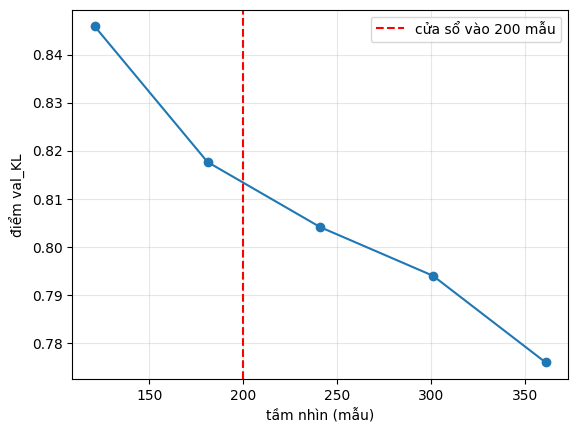

In [17]:
import matplotlib.pyplot as plt
d = {RF[int(re.search(r"_k(\d+)_", r["run_id"]).group(1))]: float(r["score_macro"])
     for r in rows}
x = sorted(d); plt.plot(x, [d[i] for i in x], "o-")
plt.axvline(200, ls="--", c="r", label="cửa sổ vào 200 mẫu")
plt.xlabel("tầm nhìn (mẫu)"); plt.ylabel("điểm val_KL"); plt.legend(); plt.grid(alpha=.3)

## 7. Ngắt phiên

In [ ]:
from google.colab import runtime
runtime.unassign()